Dataset Sample:

   mean radius  mean texture  mean area  kidney_disease
0        17.99         10.38     1001.0               0
1        20.57         17.77     1326.0               0
2        19.69         21.25     1203.0               0
3        11.42         20.38      386.1               0
4        20.29         14.34     1297.0               0

Model Accuracy: 0.9649122807017544

Confusion Matrix:

[[40  3]
 [ 1 70]]

Prediction Results:

   Actual  Predicted
0       1          1
1       0          0
2       0          0
3       1          1
4       1          1


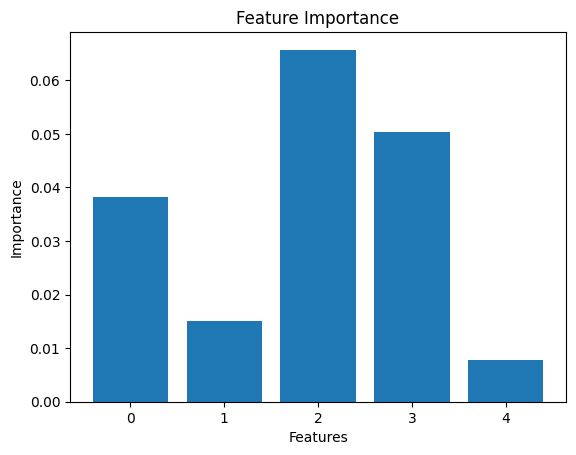


Kidney Disease Prediction Completed


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['kidney_disease'] = data.target

print("Dataset Sample:\n")
print(df.iloc[:5, [0, 1, 3, -1]])

X = df.drop('kidney_disease', axis=1)
y = df['kidney_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

result = pd.DataFrame({
    'Actual': y_test.values[:5],
    'Predicted': y_pred[:5]
})

print("\nPrediction Results:\n")
print(result)

plt.bar(range(5), model.feature_importances_[:5])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

print("\nKidney Disease Prediction Completed")
